In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.quantization
import torch.nn.functional as F
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

In [2]:
X,y = make_moons(n_samples=5000,noise=0.5,random_state=42)

In [3]:
X

array([[ 0.64527536,  1.38251014],
       [ 0.14514823, -0.32157033],
       [ 0.11945131,  0.41631146],
       ...,
       [ 0.6360473 ,  0.66530771],
       [ 1.61542641, -0.24249711],
       [ 0.10599548,  1.0899585 ]])

In [5]:
X.shape

(5000, 2)

In [4]:
y

array([0, 1, 1, ..., 1, 1, 0])

In [6]:
y.shape

(5000,)

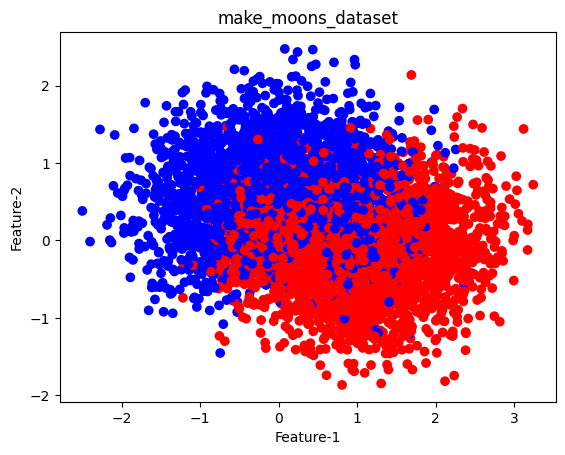

In [8]:
import matplotlib.pyplot as plt
X,y = make_moons(n_samples=5000,noise=0.5,random_state=42)
plt.scatter(X[:,0],X[:,1],c=y,cmap="bwr")
plt.title("make_moons_dataset")
plt.xlabel("Feature-1")
plt.ylabel("Feature-2")
plt.show()

In [9]:
X = StandardScaler().fit_transform(X)

In [10]:
X = torch.tensor(X, dtype=torch.float32)

In [11]:
y = torch.tensor(y.reshape(-1,1),dtype=torch.float32)

In [12]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

### Define Model (Your BigMLP)

In [13]:
class BigMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 64)
        self.fc4 = nn.Linear(64, 32)
        self.fc5 = nn.Linear(32, 16)
        self.fc6 = nn.Linear(16, 8)
        self.fc7 = nn.Linear(8, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        x = F.relu(self.fc5(x))
        x = F.relu(self.fc6(x))
        return torch.sigmoid(self.fc7(x))

### Train FP32 Model

In [17]:
model_fp32 = BigMLP()
criterion = nn.BCELoss()
optimizer = optim.Adam(model_fp32.parameters(), lr=0.01)

epochs = 20

for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model_fp32(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

print("FP32 Training Done")

FP32 Training Done


### Evaluation

In [18]:
def accuracy(model, X, y):
    model.eval()
    with torch.no_grad():
        outputs = model(X)              # probabilities
        preds = (outputs > 0.5).float() # threshold
        correct = (preds == y).float().sum()
        acc = correct / y.shape[0]
    return acc.item()


In [19]:
train_acc = accuracy(model_fp32, X_train, y_train)
test_acc = accuracy(model_fp32, X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)


Train Accuracy: 0.812250018119812
Test Accuracy: 0.828000009059906


### DO DYNAMIC QUANTIZATION



1.   Converts Linear layer weights from FP32 → INT8

Keeps activations in FP32

Quantizes weights on-the-fly during inference

Requires no retraining




In [20]:
from torch.quantization import quantize_dynamic

In [21]:
model_int8 = quantize_dynamic(
    model_fp32,
    {nn.Linear},
    dtype = torch.qint8
)

/tmp/ipython-input-2551362367.py:1: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_int8 = quantize_dynamic(


In [24]:
model_int8

BigMLP(
  (fc1): DynamicQuantizedLinear(in_features=2, out_features=128, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
  (fc2): DynamicQuantizedLinear(in_features=128, out_features=64, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
  (fc3): DynamicQuantizedLinear(in_features=64, out_features=64, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
  (fc4): DynamicQuantizedLinear(in_features=64, out_features=32, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
  (fc5): DynamicQuantizedLinear(in_features=32, out_features=16, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
  (fc6): DynamicQuantizedLinear(in_features=16, out_features=8, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
  (fc7): DynamicQuantizedLinear(in_features=8, out_features=1, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
)

In [23]:
print("INT8 Quantization Accuracy", accuracy(model_int8,X_test,y_test))

INT8 Quantization Accuracy 0.8320000171661377


In [25]:
import os
torch.save(model_fp32.state_dict(),"model_fp32.pt")
torch.save(model_int8.state_dict(),"model_dynamicptq_int8.pt")

In [26]:
os.path.getsize("model_fp32.pt")/1e6

0.067317

In [27]:
os.path.getsize("model_dynamicptq_int8.pt")/1e6

0.026475